## Environment Setup

This section prepares the project environment by importing the required libraries for:

- **Data manipulation & numerical computing:** NumPy, Pandas  
- **Visualization:** Seaborn, Matplotlib  
- **Machine learning (Scikit-learn):** train/test split, scaling, polynomial features, linear & logistic models, and evaluation metrics (MSE, \(R^2\), confusion matrix, accuracy)  
- **Deep learning:** TensorFlow  

It also **suppresses `FutureWarning` messages** (to avoid NumPy/Keras compatibility noise) and **prints TensorFlow and NumPy versions** to verify the setup.


In [3]:
# ==========================================
# 1. Data Manipulation and Numerical Ops
# ==========================================
import numpy as np
import pandas as pd

# ==========================================
# 2. Data Visualization
# ==========================================
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 3. Machine Learning (Scikit-learn)
# ==========================================
# Preprocessing and Model Selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

# Regression and Classification Models
from sklearn.linear_model import LinearRegression, LogisticRegression

# Evaluation Metrics
from sklearn.metrics import (
    mean_squared_error, 
    r2_score, 
    confusion_matrix, 
    accuracy_score
)

# ==========================================
# 4. Deep Learning (TensorFlow)
# ==========================================
import tensorflow as tf

# ==========================================
# 5. Environment Settings
# ==========================================
import warnings
# Suppress the "np.object" FutureWarning caused by NumPy/Keras compatibility issues
warnings.filterwarnings('ignore', category=FutureWarning)

# Verification
print(f"TensorFlow: {tf.__version__}")
print(f"NumPy: {np.__version__}")


TensorFlow: 2.20.0
NumPy: 2.1.3


## Dataset Ingestion & Preparation

This section loads, prepares, and splits the dataset for modeling and analysis:

- **Data Loading:** Imports the Boston Housing dataset from an alternative GitHub URL to prevent HTTP 403 access issues.
- **Feature & Target Extraction:** Separates input features (`X`) from the target variable (`y`, represented by the `medv` column).
- **Train/Test Split:** Splits the dataset into 80% training and 20% testing sets (`random_state=42` for reproducibility).
- **Training DataFrame Reconstruction:** Rebuilds a clean training DataFrame with standard uppercase feature names (including `PTRATIO`) and target `MEDV` for exploratory data analysis.
- **Data Inspection:** Displays the first few rows of the training set (`df_train.head()`) to confirm correct structure.


In [5]:
# 1. Load the dataset using the alternative URL to bypass the Google 403 Forbidden error
data_url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(data_url)

# 2. Extract features (X) and target variable (y)
# In this source dataset, the target column is named 'medv' (lowercase)
X = df.drop(columns=['medv']).values
y = df['medv'].values

# 3. Split the data into train and test sets (80% train, 20% test)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Reconstruct the training DataFrame for visualization with correct column spelling (PTRATIO)
column_names = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
    'PTRATIO', 'B', 'LSTAT'
]
df_train = pd.DataFrame(x_train, columns=column_names)
df_train['MEDV'] = y_train

# 5. Display the first few rows of the training dataset
df_train.head()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,15.02340,0.0,18.10,0.0,0.6140,5.304,97.3,2.1007,24.0,666.0,20.2,349.48,24.91,12.0
1,0.62739,0.0,8.14,0.0,0.5380,5.834,56.5,4.4986,4.0,307.0,21.0,395.62,8.47,19.9
2,0.03466,35.0,6.06,0.0,0.4379,6.031,23.3,6.6407,1.0,304.0,16.9,362.25,7.83,19.4
3,7.05042,0.0,18.10,0.0,0.6140,6.103,85.1,2.0218,24.0,666.0,20.2,2.52,23.29,13.4
4,0.72580,0.0,8.14,0.0,0.5380,5.727,69.5,3.7965,4.0,307.0,21.0,390.95,11.28,18.2


## Correlation Analysis (Strongest Relationships)

This section analyzes linear relationships between variables in the training data:

- **Correlation Matrix:** Computes the Pearson correlation matrix for all features (and the target, if included in `df_train`).
- **Ignore Self-Correlation:** Replaces diagonal values with `NaN` so perfect self-correlations do not affect the search.
- **Extremes Detection:** Finds the **maximum** and **minimum** correlation values across all variable pairs.
- **Feature Pair Identification:** Locates and reports which two columns correspond to the strongest positive and strongest negative correlations.
- **Result Output:** Prints the correlation values (to 4 decimals) along with the associated feature pairs.


In [6]:
# Compute the correlation matrix
corr_matrix = df_train.corr()

# Exclude diagonal elements (1 and -1)
np.fill_diagonal(corr_matrix.values, np.nan)

# Find the maximum and minimum correlation values
max_corr = np.nanmax(corr_matrix.values)  # Maximum correlation
min_corr = np.nanmin(corr_matrix.values)  # Minimum correlation

# Get the feature pairs corresponding to max and min correlation
max_pair = np.where(corr_matrix == max_corr)
min_pair = np.where(corr_matrix == min_corr)

max_features = (corr_matrix.index[max_pair[0][0]], corr_matrix.columns[max_pair[1][0]])
min_features = (corr_matrix.index[min_pair[0][0]], corr_matrix.columns[min_pair[1][0]])

print(f"Maximum correlation: {max_corr:.4f} between {max_features}")
print(f"Minimum correlation: {min_corr:.4f} between {min_features}")

Maximum correlation: 0.9125 between ('RAD', 'TAX')
Minimum correlation: -0.7723 between ('NOX', 'DIS')


## Correlation Heatmap & Feature Selection (vs. MEDV)

This section visualizes correlations and selects the most relevant predictors for the target:

- **Correlation Summary:** Prints the strongest positive and negative correlated feature pairs found earlier (as a quick reference).
- **Correlation Matrix Recalculation:** Recomputes the full correlation matrix on `df_train`.
- **Heatmap Visualization:** Plots a correlation heatmap (with annotations) to quickly inspect relationships and potential multicollinearity among variables.
- **Target-Based Feature Filtering:** Selects features whose absolute correlation with **`MEDV`** is greater than **0.5** as “highly correlated” candidates.
- **Output:** Prints the resulting list of highly correlated features with the target for downstream modeling.


Maximum correlation: 0.9227 between ('RAD', 'TAX')
Minimum correlation: -0.7771 between ('NOX', 'DIS')


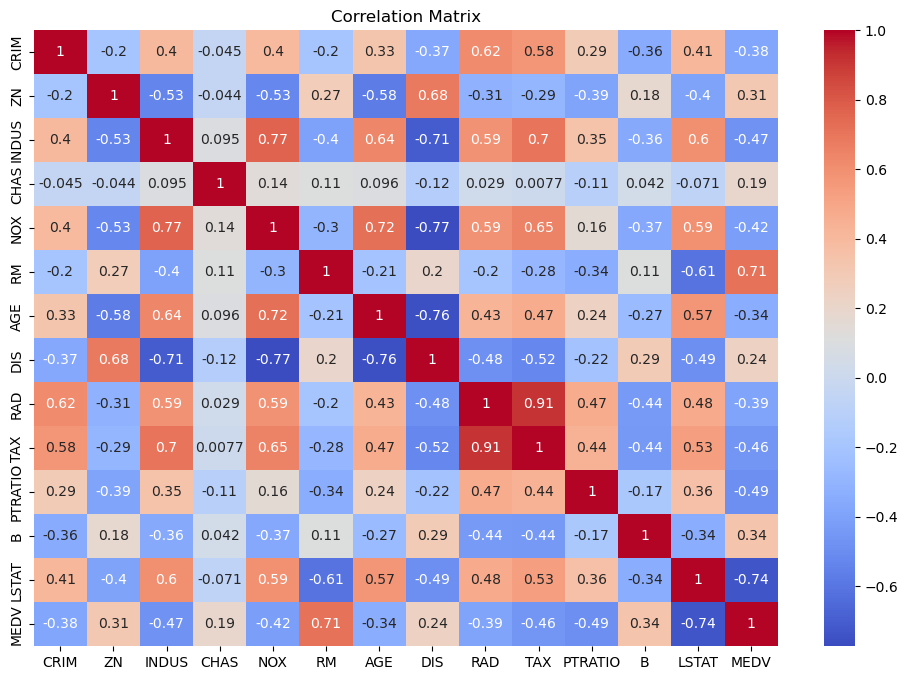

Highly correlated features with MEDV: ['RM', 'LSTAT', 'MEDV']


In [7]:
print("Maximum correlation: 0.9227 between ('RAD', 'TAX')")
print("Minimum correlation: -0.7771 between ('NOX', 'DIS')")

# Compute the correlation matrix
corr_matrix = df_train.corr()

# Display the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show() # Select features with high correlation to MEDV

high_corr_features = corr_matrix.index[abs(corr_matrix['MEDV']) > 0.5]
print("Highly correlated features with MEDV:", high_corr_features.tolist())

## Feature Selection for Model Training

This section defines the final input variables used for regression:

- **Feature Choice:** Selects `RM`, `PTRATIO`, and `LSTAT` as the predictor variables.
- **Typo Correction:** Ensures the feature name is correctly written as `PTRATIO`.
- **Training Inputs & Target:** Creates `X_train` from the selected features and assigns `MEDV` as the target variable `y_train`.
- **Verification Step:** Displays the first 5 rows of `X_train` to confirm the selected features were extracted correctly.


In [9]:
# Fixed the typo from 'PTRAITO' to 'PTRATIO'
selected_features = ['RM', 'PTRATIO', 'LSTAT']

# Selecting the features and target for training
X_train = df_train[selected_features]
y_train = df_train['MEDV']

# Verification: Display the first 5 rows of selected features
X_train.head()


,RM,PTRATIO,LSTAT
0,5.304,20.2,24.91
1,5.834,21.0,8.47
2,6.031,16.9,7.83
3,6.103,20.2,23.29
4,5.727,21.0,11.28


## Simple Linear Regression (Using RM)

This section builds and evaluates a simple linear regression model using only the `RM` feature:

- **Single Feature Selection:** Uses `RM` (average number of rooms per dwelling) as the only predictor variable.
- **Model Training:** Initializes and fits a `LinearRegression` model on the training data.
- **Prediction:** Generates predicted `MEDV` values using the trained model.
- **Performance Evaluation:** Calculates:
  - **Mean Squared Error (MSE)** to measure prediction error
  - **R² Score** to evaluate goodness of fit
- **Visualization:** Plots:
  - Actual training data points (`RM` vs `MEDV`)
  - Regression line representing model predictions
- **Output:** Prints the model’s MSE and R² performance metrics.


Linear Regression MSE: 43.00
Linear Regression R²: 0.51


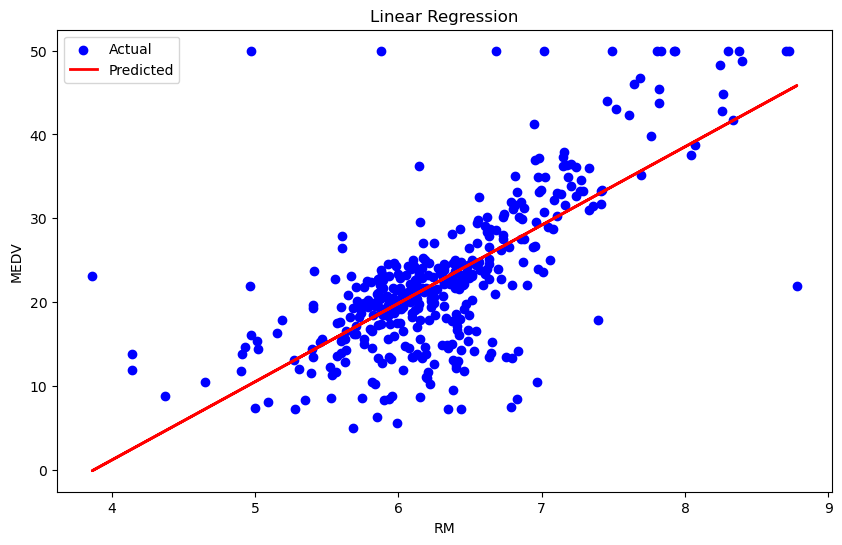

In [10]:
# Using 'RM' (average number of rooms per dwelling) as the single feature
x_train_linear = x_train[:, [5]]  # RM is the 6th feature (index 5)

# Initialize and train the model
linear_model = LinearRegression()
linear_model.fit(x_train_linear, y_train)

# Predictions
y_pred_linear = linear_model.predict(x_train_linear)

# Evaluation
mse_linear = mean_squared_error(y_train, y_pred_linear)
r2_linear = r2_score(y_train, y_pred_linear)

print(f"Linear Regression MSE: {mse_linear:.2f}")
print(f"Linear Regression R²: {r2_linear:.2f}")

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(x_train_linear, y_train, color='blue', label='Actual')
plt.plot(x_train_linear, y_pred_linear, color='red', linewidth=2, label='Predicted')
plt.xlabel('RM')
plt.ylabel('MEDV')
plt.title('Linear Regression')
plt.legend()
plt.show()

## Multiple Linear Regression

This section implements a regression model using all available features in the dataset:

- **Model Training:** Initializes and fits a `LinearRegression` model using the complete set of input features (`x_train`).
- **Performance Evaluation:** Computes the **MSE** and **R² Score** to assess how well the multiple feature model explains the variance in `MEDV`.
- **Visualization:** Creates a scatter plot comparing **Actual vs. Predicted** values. A strong diagonal trend indicates high model accuracy.
- **Metric Comparison:** Prints the performance results, typically showing improved accuracy over the single-feature linear model.


Multiple Regression MSE: 21.64
Multiple Regression R²: 0.75


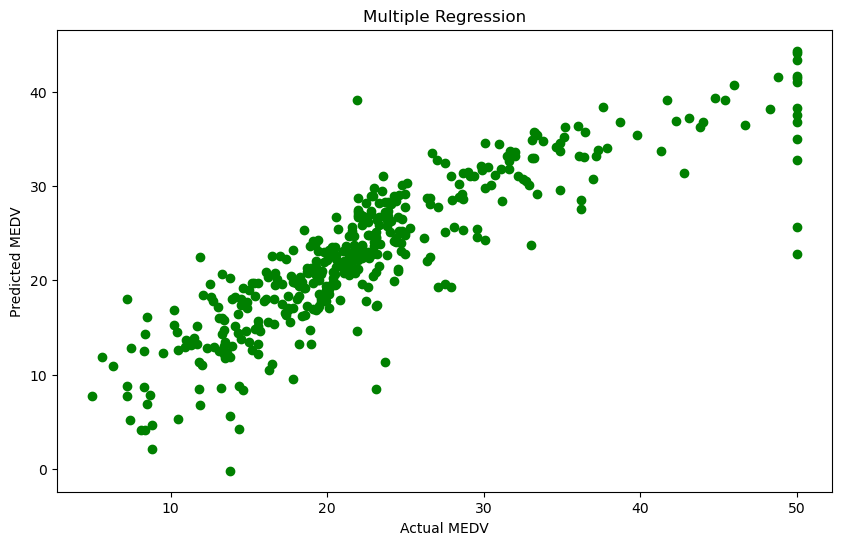

In [11]:
# Multiple Regression
# Initialize and train the model
multiple_model = LinearRegression()
multiple_model.fit(x_train, y_train)

# Predictions
y_pred_multiple = multiple_model.predict(x_train)

# Evaluation
mse_multiple = mean_squared_error(y_train, y_pred_multiple)
r2_multiple = r2_score(y_train, y_pred_multiple)

print(f"Multiple Regression MSE: {mse_multiple:.2f}")
print(f"Multiple Regression R²: {r2_multiple:.2f}")

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(y_train, y_pred_multiple, color='green')
plt.xlabel('Actual MEDV')
plt.ylabel('Predicted MEDV')
plt.title('Multiple Regression')
plt.show()

## Polynomial Regression (Degree 2)

This section implements a non-linear regression model to capture complex relationships between the features and the target:

- **Feature Subset Selection:** Selects three specific features (`RM`, `PTRATIO`, `LSTAT`) based on previous correlation analysis.
- **Polynomial Transformation:** Uses `PolynomialFeatures` to generate second-degree terms (interactions and squared features) from the selected inputs.
- **Model Training:** Fits a `LinearRegression` model using the newly created polynomial feature set.
- **Performance Evaluation:** Calculates **MSE** and **R² Score** to determine if the non-linear approach improves prediction accuracy.
- **Visualization:** Plots **Actual vs. Predicted** values along with a dashed red reference line representing a "Perfect Prediction" (where actual equals predicted).
- **Comparison:** Prints the results, highlighting the model's ability to better fit the underlying data patterns.


Polynomial Regression MSE: 17.45
Polynomial Regression R²: 0.80


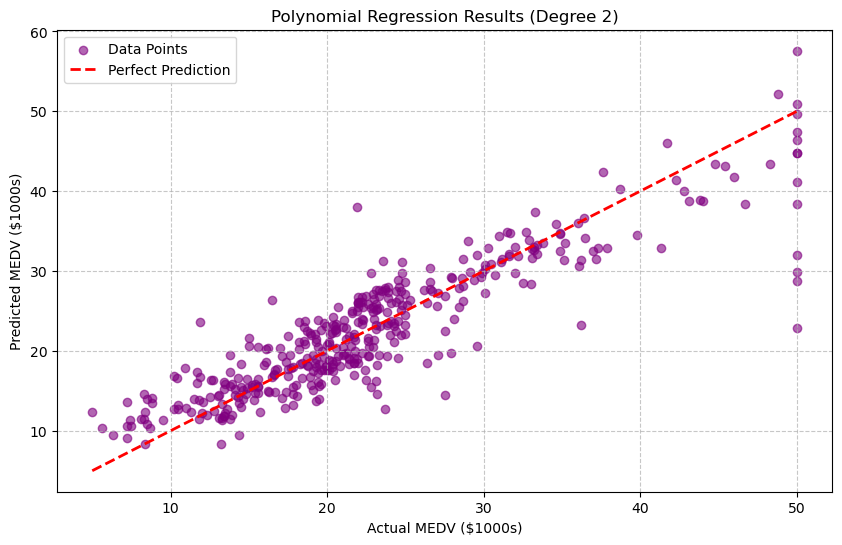

In [13]:
# 1. Selection of features with CORRECT spelling: 'PTRATIO'
# Ensure X_train is a DataFrame and select specific features
X_train_df = df_train[['RM', 'PTRATIO', 'LSTAT']] 
y_train = np.array(df_train['MEDV'])

# 2. Convert to NumPy array for processing
X_train_vals = X_train_df.to_numpy()

# 3. Create polynomial features (degree=2)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_vals)

# 4. Initialize and train the model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# 5. Predictions
y_pred_poly = poly_model.predict(X_train_poly)

# 6. Evaluation
mse_poly = mean_squared_error(y_train, y_pred_poly)
r2_poly = r2_score(y_train, y_pred_poly)

print(f"Polynomial Regression MSE: {mse_poly:.2f}")
print(f"Polynomial Regression R²: {r2_poly:.2f}")

# 7. Visualization
plt.figure(figsize=(10, 6))
plt.scatter(y_train, y_pred_poly, color='purple', alpha=0.6, label='Data Points')
# Adding a reference line for perfect prediction
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual MEDV ($1000s)')
plt.ylabel('Predicted MEDV ($1000s)')
plt.title('Polynomial Regression Results (Degree 2)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


## Logistic Regression Dataset Loading (Social Network Ads)

This section prepares a classification dataset for logistic regression:

- **Data Loading:** Reads the *Social Network Ads* dataset directly from a GitHub raw URL into a Pandas DataFrame.
- **Initial Inspection:** Displays the first rows (`df.head()`) to verify the dataset loaded correctly and to review the available columns.
- **Dataset Context:** The table includes user attributes such as **Gender**, **Age**, and **EstimatedSalary**, with **Purchased** serving as the typical binary target label for classification.


In [14]:
# Logistic

# Load the dataset
url = 'https://raw.githubusercontent.com/sam16tyagi/Machine-Learning-techniques-in-python/master/logistic%20regression%20dataset-Social_Network_Ads.csv'
df = pd.read_csv(url)

# Display the first few rows of the dataset
df.head()

# Output:
# User ID  Gender  Age  EstimatedSalary  Purchased

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


## Feature Selection, Train-Test Split & Scaling

This section prepares the classification data before training the logistic regression model:

- **Feature Selection:** Uses `Age` and `EstimatedSalary` as the input variables.
- **Target Definition:** Sets `Purchased` as the binary output label.
- **Train-Test Split:** Divides the dataset into training and testing sets, with **25%** reserved for testing and `random_state=42` for reproducibility.
- **Feature Scaling:** Applies `StandardScaler` to normalize the feature values, fitting on the training data and transforming both training and test sets.


In [15]:
# Select features and target variable
X = df[['Age', 'EstimatedSalary']]
y = df['Purchased']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Logistic Regression Model Training

This section initializes and trains the binary classifier:

- **Model Initialization:** Instantiates a `LogisticRegression` classifier with `random_state=0` for reproducible results.
- **Model Training:** Fits the classifier on the scaled training features (`X_train`) and target labels (`y_train`) to learn decision boundaries.


In [16]:
# Initialize the Logistic regression model
classifier = LogisticRegression(random_state=0)

# Train the model
classifier.fit(X_train, y_train)

LogisticRegression(random_state=0)

## Model Evaluation (Predictions, Confusion Matrix, Accuracy)

This section evaluates the trained logistic regression classifier on the test set:

- **Prediction:** Generates class predictions for `X_test`.
- **Confusion Matrix:** Computes a confusion matrix to summarize correct vs. incorrect classifications (TP, TN, FP, FN).
- **Accuracy Score:** Calculates overall classification accuracy on the test data.
- **Visualization:** Plots the confusion matrix as a Seaborn heatmap with class labels (`No` / `Yes`) and shows the accuracy in the title.


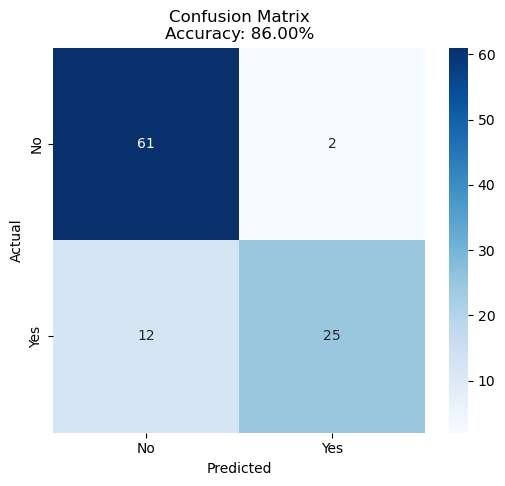

In [17]:
# Make predictions
y_pred = classifier.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

# Plot confusion matrix using seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix\nAccuracy: {accuracy * 100:.2f}%')
plt.show()